# XGBoost for Wind Power Forecasting

This notebook trains and evaluates an XGBoost regressor to predict the wind farm `capacity_factor`.

We rely on:
- precomputed train/test parquet files
- shared utilities from `utils.py`
- time-based expanding-window cross-validation

Main objectives:
1. Load the prepared datasets
2. Rebuild the temporal CV folds
3. Train and validate an XGBoost model
4. Retrain on the full training set
5. Evaluate on the held-out test set
6. Analyze feature importance and forecast quality

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from utils import (
    load_data,
    get_cv_folds,
    evaluate,
    plot_forecast,
    plot_forecast_zoom,
)

## 1. Load preprocessed datasets

We load:
- training and test feature matrices
- target vectors
- metadata (time, site, installed capacity)
- site mapping

The metadata is required for:
- rebuilding temporal folds
- per-site evaluation
- plotting forecasts

In [2]:
X_train, y_train, X_test, y_test, meta_train, meta_test, site_mapping = load_data()

X_train : (248304, 77)  |  X_test : (26390, 77)
Train period : 2023-01-01 → 2025-10-31
Test  period : 2025-11-01 → 2026-02-18
Sites : 10


## 2. Sanity checks

We verify that:
- train and metadata have aligned lengths
- test and metadata have aligned lengths
- delivery times are chronologically sorted

In [3]:
assert len(X_train) == len(y_train) == len(meta_train), "Train data misalignment"
assert len(X_test) == len(y_test) == len(meta_test), "Test data misalignment"

assert meta_train["delivery_time"].is_monotonic_increasing, "meta_train must be sorted by time"
assert meta_test["delivery_time"].is_monotonic_increasing, "meta_test must be sorted by time"

print("All checks passed.")

All checks passed.


## 3. Time-based cross-validation

We reconstruct the same expanding-window CV strategy used in preprocessing:
- training always starts from the beginning
- validation windows move forward chronologically
- each validation block spans 90 days

This ensures realistic temporal validation.

In [4]:
folds = get_cv_folds(meta_train["delivery_time"])

CV: 6 folds | val window = 90 days | expanding train
  Fold 1: train 2023-01-01 → 2024-05-09  |  val 2024-05-09 → 2024-08-07  (118,790 / 21,552 rows)
  Fold 2: train 2023-01-01 → 2024-08-07  |  val 2024-08-07 → 2024-11-05  (140,342 / 21,600 rows)
  Fold 3: train 2023-01-01 → 2024-11-05  |  val 2024-11-05 → 2025-02-03  (161,942 / 21,600 rows)
  Fold 4: train 2023-01-01 → 2025-02-03  |  val 2025-02-03 → 2025-05-04  (183,542 / 21,552 rows)
  Fold 5: train 2023-01-01 → 2025-05-04  |  val 2025-05-04 → 2025-08-02  (205,094 / 21,600 rows)
  Fold 6: train 2023-01-01 → 2025-08-02  |  val 2025-08-02 → 2025-10-31  (226,694 / 21,600 rows)


## 4. Feature compatibility checks

XGBoost expects numerical inputs.
We convert boolean columns if needed.

In [5]:
X_train_model = X_train.copy()
X_test_model = X_test.copy()

for col in X_train_model.columns:
    if pd.api.types.is_bool_dtype(X_train_model[col]):
        X_train_model[col] = X_train_model[col].astype(int)
        X_test_model[col] = X_test_model[col].astype(int)

print(X_train_model.dtypes.value_counts())

float64    77
Name: count, dtype: int64


## 5. XGBoost configuration

We start from a regularized configuration to reduce over-reliance on a single dominant feature
and encourage better generalization across time.

In [6]:
xgb_params = {
    "objective": "reg:squarederror",
    "n_estimators": 5000,
    "learning_rate": 0.02,
    "max_depth": 4,
    "min_child_weight": 10,
    "subsample": 0.7,
    "colsample_bytree": 0.6,
    "reg_alpha": 1.0,
    "reg_lambda": 5.0,
    "gamma": 1.0,
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist",
    "eval_metric": "rmse",
}
xgb_params

{'objective': 'reg:squarederror',
 'n_estimators': 5000,
 'learning_rate': 0.02,
 'max_depth': 4,
 'min_child_weight': 10,
 'subsample': 0.7,
 'colsample_bytree': 0.6,
 'reg_alpha': 1.0,
 'reg_lambda': 5.0,
 'gamma': 1.0,
 'random_state': 42,
 'n_jobs': -1,
 'tree_method': 'hist',
 'eval_metric': 'rmse'}

## 6. Cross-validation training

For each fold:
- fit the model on the training window
- predict on the validation window
- compute global and per-site metrics
- store out-of-fold predictions

This gives a robust estimate of temporal generalization.

In [7]:
cv_rows = []
oof_pred = np.full(len(X_train_model), np.nan)
best_iterations = []

for fold_id, (tr_idx, val_idx) in enumerate(folds, start=1):
    X_tr = X_train_model.iloc[tr_idx]
    y_tr = y_train.iloc[tr_idx]

    X_val = X_train_model.iloc[val_idx]
    y_val = y_train.iloc[val_idx]

    model = XGBRegressor(**xgb_params)

    try:
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            early_stopping_rounds=100,
            verbose=False,
        )
    except TypeError:
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )

    best_iter = getattr(model, "best_iteration", None)
    if best_iter is None:
        best_iter = xgb_params["n_estimators"] - 1

    best_iterations.append(best_iter)

    pred_val = model.predict(X_val)
    oof_pred[val_idx] = pred_val

    metrics, _ = evaluate(
        y_true=y_val,
        y_pred=pred_val,
        site_names=meta_train.iloc[val_idx]["site_name"].values,
        model_name=f"XGBoost CV Fold {fold_id}"
    )

    cv_rows.append({
        "split": f"CV Fold {fold_id}",
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "nRMSE": metrics["nRMSE"],
        "best_iteration": best_iter,
        "n_train": len(tr_idx),
        "n_val": len(val_idx),
    })

[XGBoost CV Fold 1]  Global — MAE=0.0520  RMSE=0.0823  nRMSE=0.0832  (n=21,552)
                                     MAE    RMSE   nRMSE     n
site                                                          
Mermaid Offshore WP               0.0626  0.1025  0.1042  2160
Seastar Offshore WP               0.0624  0.0958  0.0971  2160
Norther Offshore WP               0.0635  0.0943  0.1003  2136
Northwester 2                     0.0474  0.0822  0.0917  2160
Nobelwind Offshore Windpark       0.0524  0.0815  0.0843  2160
Rentel Offshore WP                0.0489  0.0762  0.0770  2136
Thorntonbank - C-Power - Area SW  0.0481  0.0750  0.0772  2160
Northwind                         0.0486  0.0722  0.0749  2160
Thorntonbank - C-Power - Area NE  0.0444  0.0702  0.0748  2160
Belwind Phase 1                   0.0413  0.0652  0.0685  2160
[XGBoost CV Fold 2]  Global — MAE=0.0669  RMSE=0.1073  nRMSE=0.1084  (n=21,600)
                                     MAE    RMSE   nRMSE     n
site                 

## 7. Cross-validation summary

We summarize fold-wise metrics and compute:
- mean CV performance
- out-of-fold (OOF) performance across all validation points

In [8]:
cv_results_df = pd.DataFrame(cv_rows)
display(cv_results_df)

oof_metrics, oof_per_site = evaluate(
    y_true=y_train,
    y_pred=oof_pred,
    site_names=meta_train["site_name"].values,
    model_name="XGBoost OOF CV"
)

summary_rows = cv_results_df[["split", "MAE", "RMSE", "nRMSE"]].to_dict(orient="records")
summary_rows.append({
    "split": "CV Mean",
    "MAE": cv_results_df["MAE"].mean(),
    "RMSE": cv_results_df["RMSE"].mean(),
    "nRMSE": cv_results_df["nRMSE"].mean(),
})
summary_rows.append({
    "split": "OOF CV",
    "MAE": oof_metrics["MAE"],
    "RMSE": oof_metrics["RMSE"],
    "nRMSE": oof_metrics["nRMSE"],
})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,split,MAE,RMSE,nRMSE,best_iteration,n_train,n_val
0,CV Fold 1,0.051951,0.082329,0.083208,4999,118790,21552
1,CV Fold 2,0.066950,0.107250,0.108365,4999,140342,21600
2,CV Fold 3,0.057943,0.086728,0.087533,4999,161942,21600
3,CV Fold 4,0.058925,0.088664,0.089638,4999,183542,21552
4,CV Fold 5,0.067537,0.104703,0.105867,4999,205094,21600
5,CV Fold 6,0.067929,0.099951,0.100950,4999,226694,21600


[XGBoost OOF CV]  Global — MAE=0.0619  RMSE=0.0954  nRMSE=0.0963  (n=129,504)
                                     MAE    RMSE   nRMSE      n
site                                                           
Norther Offshore WP               0.0721  0.1136  0.1171  12936
Mermaid Offshore WP               0.0695  0.1054  0.1071  12960
Northwester 2                     0.0650  0.1021  0.1040  12960
Seastar Offshore WP               0.0685  0.0996  0.1007  12960
Nobelwind Offshore Windpark       0.0620  0.0951  0.0963  12960
Rentel Offshore WP                0.0603  0.0926  0.0935  12936
Northwind                         0.0598  0.0897  0.0909  12936
Thorntonbank - C-Power - Area SW  0.0563  0.0867  0.0880  12960
Thorntonbank - C-Power - Area NE  0.0540  0.0847  0.0865  12936
Belwind Phase 1                   0.0512  0.0795  0.0821  12960


,split,MAE,RMSE,nRMSE
0,CV Fold 1,0.051951,0.082329,0.083208
1,CV Fold 2,0.066950,0.107250,0.108365
2,CV Fold 3,0.057943,0.086728,0.087533
3,CV Fold 4,0.058925,0.088664,0.089638
4,CV Fold 5,0.067537,0.104703,0.105867
5,CV Fold 6,0.067929,0.099951,0.100950
6,CV Mean,0.061873,0.094938,0.095927
7,OOF CV,0.061877,0.095415,0.096301


## 8. Fold-wise metric stability

We visualize fold-to-fold variability to identify
potential temporal drift or difficult validation periods.

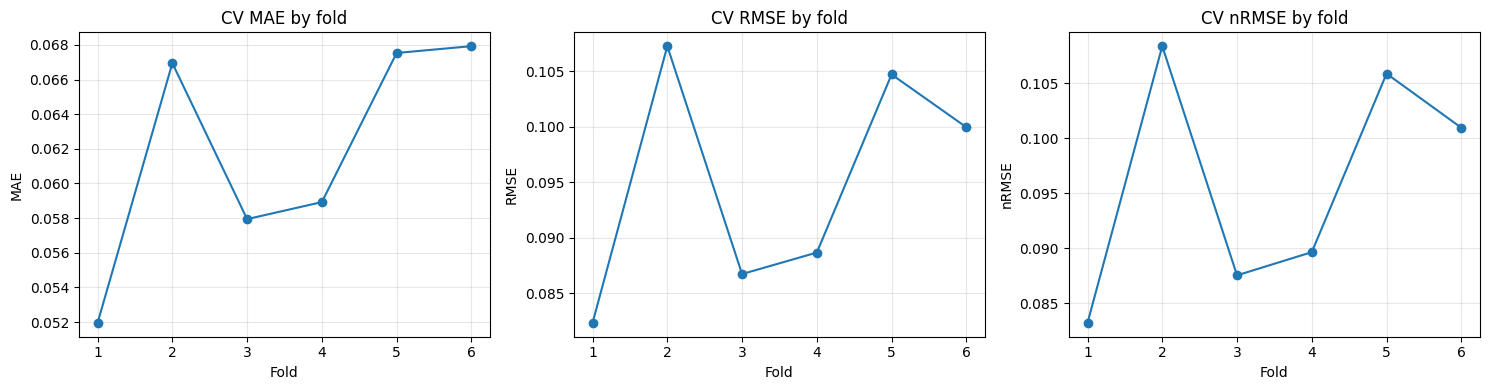

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["MAE", "RMSE", "nRMSE"]):
    ax.plot(range(1, len(cv_results_df) + 1), cv_results_df[metric], marker="o")
    ax.set_title(f"CV {metric} by fold")
    ax.set_xlabel("Fold")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Final training on the full training set

We retrain the model on all available training data.
The final number of trees is chosen from the median best iteration across folds.

In [10]:
final_n_estimators = int(np.median(best_iterations)) + 1
print("Best iterations:", best_iterations)
print("Chosen final_n_estimators:", final_n_estimators)

final_params = xgb_params.copy()
final_params["n_estimators"] = final_n_estimators

final_model = XGBRegressor(**final_params)
final_model.fit(X_train_model, y_train, verbose=False)

test_pred = final_model.predict(X_test_model)

Best iterations: [4999, 4999, 4999, 4999, 4999, 4999]
Chosen final_n_estimators: 5000


## 10. Held-out test evaluation

We evaluate the final model on the future held-out test period.
This is the most important estimate of real-world forecasting performance.

In [11]:
test_metrics, test_per_site = evaluate(
    y_true=y_test,
    y_pred=test_pred,
    site_names=meta_test["site_name"].values,
    model_name="XGBoost Test"
)

summary_df = pd.concat([
    summary_df,
    pd.DataFrame([{
        "split": "Held-out Test",
        "MAE": test_metrics["MAE"],
        "RMSE": test_metrics["RMSE"],
        "nRMSE": test_metrics["nRMSE"],
    }])
], ignore_index=True)

display(summary_df)

[XGBoost Test]  Global — MAE=0.0763  RMSE=0.1059  nRMSE=0.1068  (n=26,390)
                                     MAE    RMSE   nRMSE     n
site                                                          
Northwester 2                     0.0985  0.1282  0.1305  2639
Norther Offshore WP               0.0843  0.1144  0.1179  2639
Mermaid Offshore WP               0.0798  0.1106  0.1124  2639
Seastar Offshore WP               0.0766  0.1027  0.1039  2639
Nobelwind Offshore Windpark       0.0723  0.1020  0.1033  2639
Northwind                         0.0722  0.1011  0.1025  2639
Thorntonbank - C-Power - Area NE  0.0702  0.1011  0.1032  2639
Belwind Phase 1                   0.0702  0.0991  0.1032  2639
Rentel Offshore WP                0.0696  0.0979  0.0988  2639
Thorntonbank - C-Power - Area SW  0.0694  0.0977  0.0992  2639


,split,MAE,RMSE,nRMSE
0,CV Fold 1,0.051951,0.082329,0.083208
1,CV Fold 2,0.066950,0.107250,0.108365
2,CV Fold 3,0.057943,0.086728,0.087533
3,CV Fold 4,0.058925,0.088664,0.089638
4,CV Fold 5,0.067537,0.104703,0.105867
5,CV Fold 6,0.067929,0.099951,0.100950
6,CV Mean,0.061873,0.094938,0.095927
7,OOF CV,0.061877,0.095415,0.096301
8,Held-out Test,0.076306,0.105875,0.106830


## 11. Feature importance

We inspect feature importance to understand
which variables drive the model predictions.

,feature,importance
0,ws_100_cubed,0.184171
1,effective_wind_power,0.143135
2,ws_100_sq,0.132114
3,ws100_lead1h,0.130619
4,ws10_lead1h,0.096337
5,wind_speed_100m,0.067043
6,ws_10_sq,0.062358
7,wind_speed_10m,0.048185
8,ws_10_cubed,0.035824
9,gusts_lead1h,0.014971


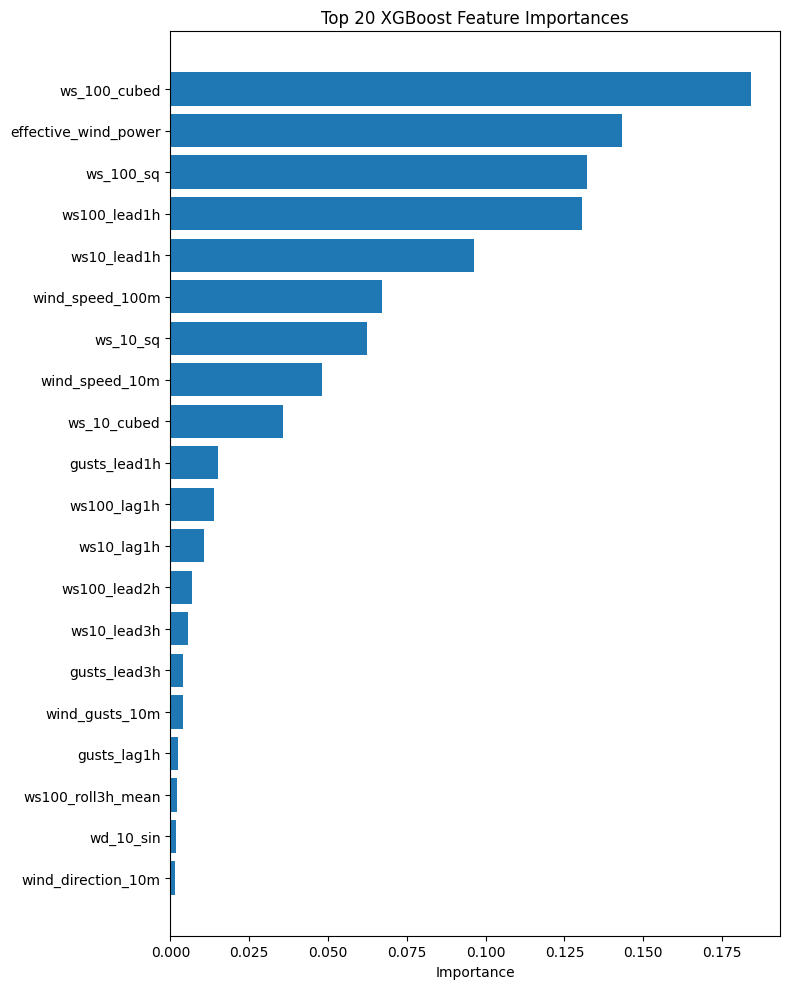

In [12]:
feat_imp = (
    pd.DataFrame({
        "feature": X_train_model.columns,
        "importance": final_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feat_imp.head(20))

plt.figure(figsize=(8, 10))
top_k = 20
plt.barh(
    feat_imp["feature"].head(top_k)[::-1],
    feat_imp["importance"].head(top_k)[::-1]
)
plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 12. Forecast visualization

We compare actual vs predicted capacity factor over time:
- one panel per site
- daily averages for readability

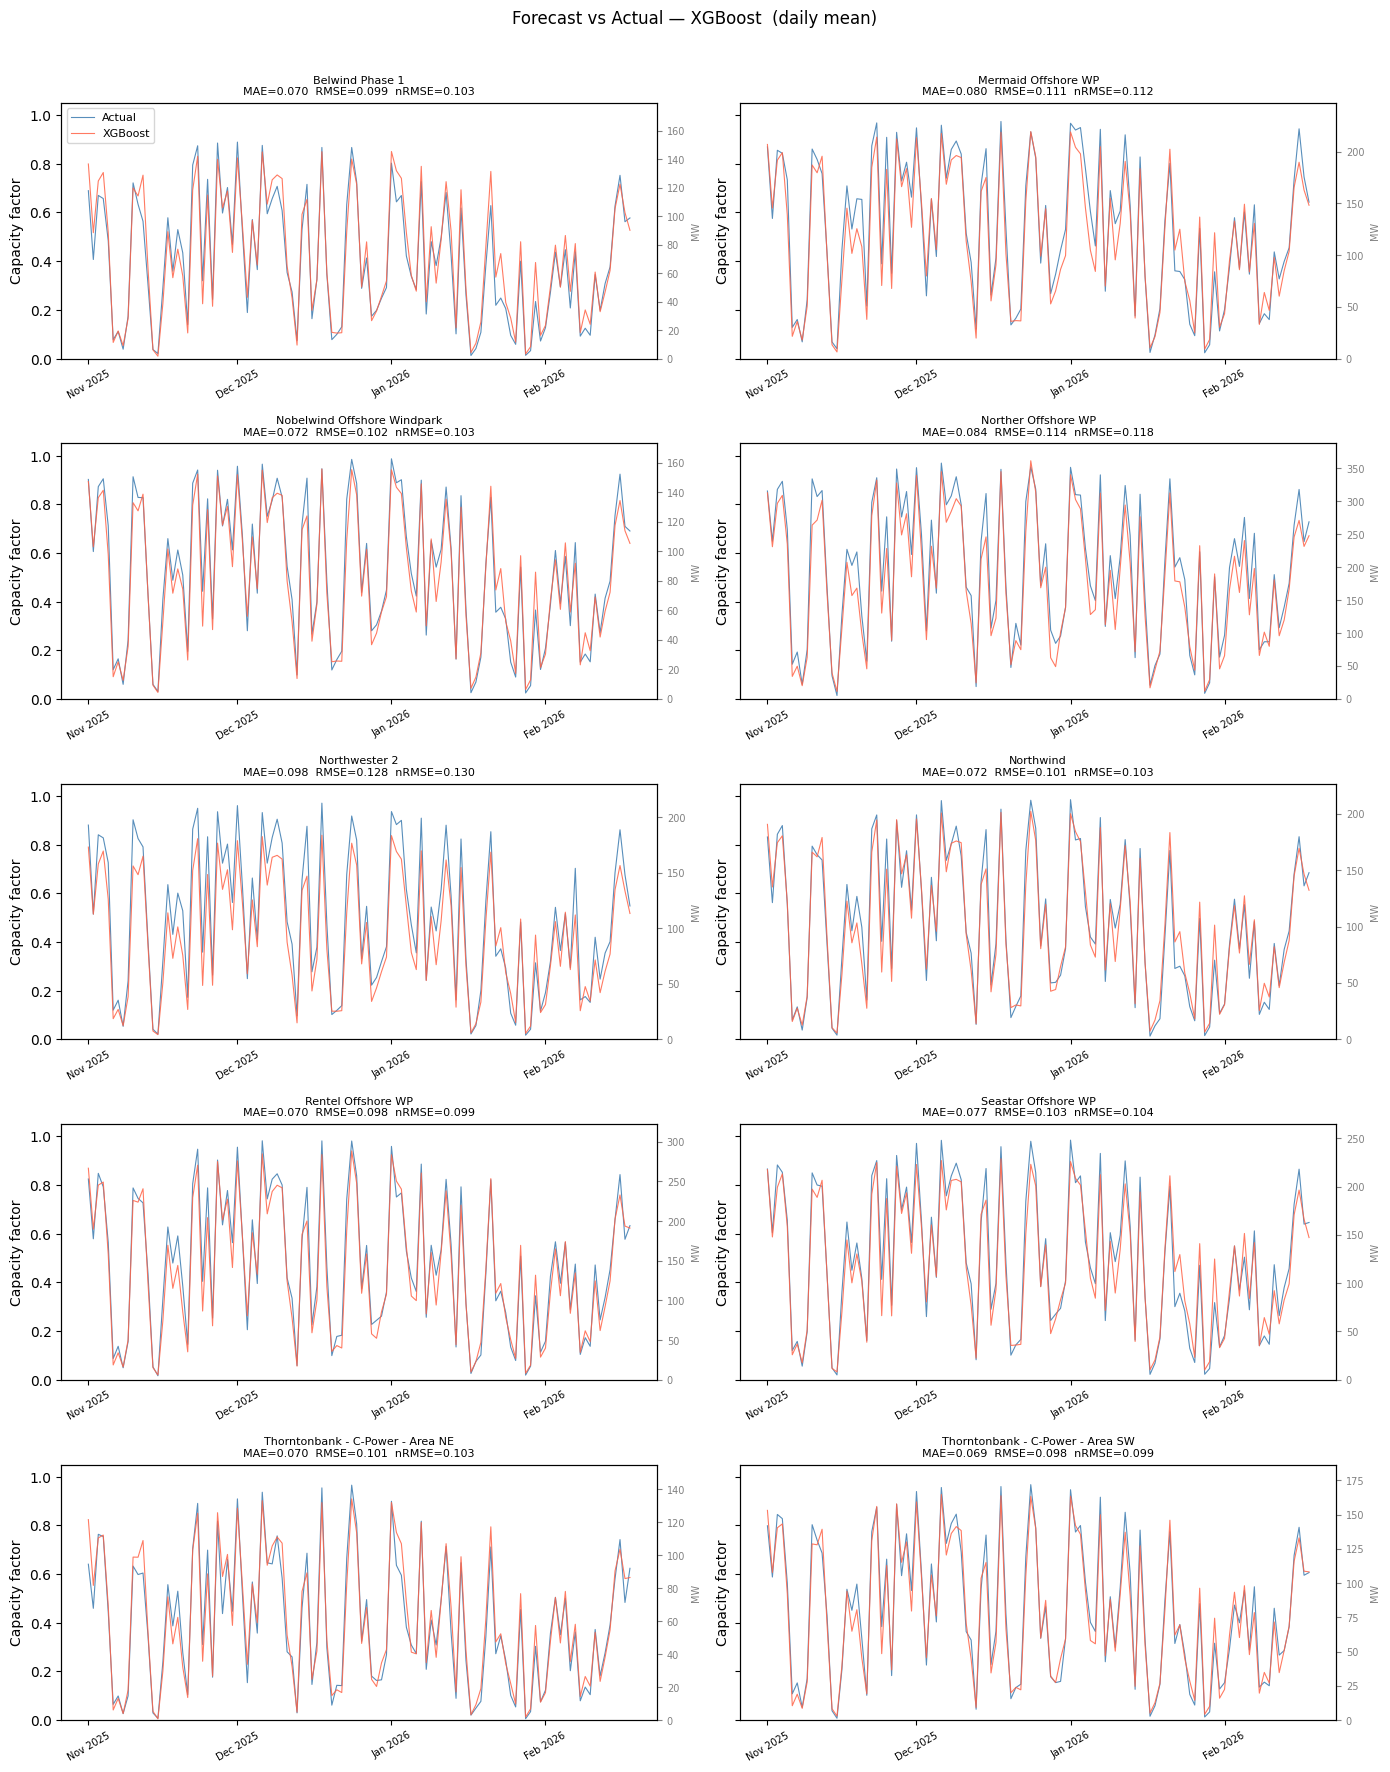

In [13]:
installed_capacity = (
    meta_test[["site_name", "installed_capacity"]]
    .drop_duplicates()
    .set_index("site_name")["installed_capacity"]
    .to_dict()
)

plot_forecast(
    delivery_times=meta_test["delivery_time"],
    y_true=y_test,
    y_pred=test_pred,
    site_names=meta_test["site_name"],
    model_name="XGBoost",
    resample="D",
    installed_capacity=installed_capacity,
    ncols=2,
)

## 13. Zoom on a specific site and period

A local zoom helps identify:
- lag effects
- underestimation of peaks
- smoothing behavior

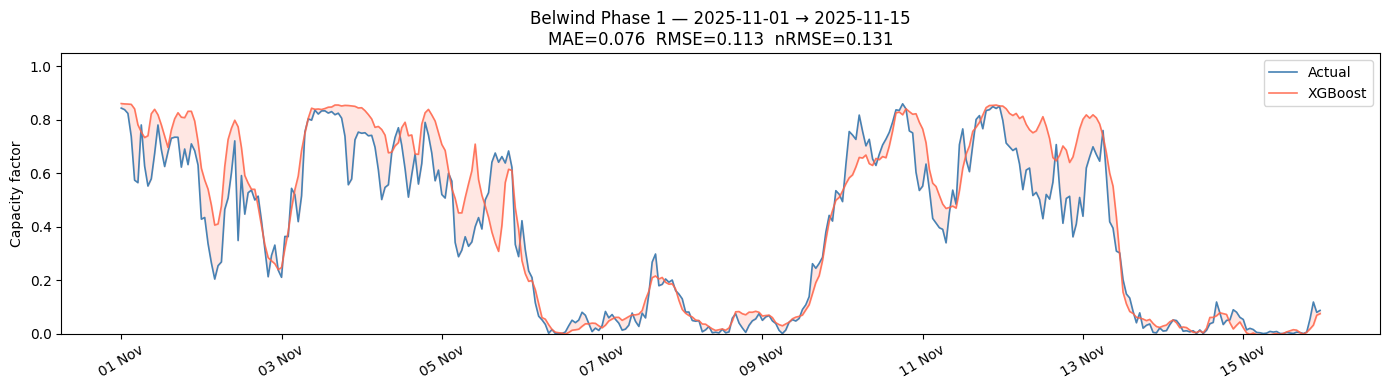

In [14]:
example_site = sorted(meta_test["site_name"].unique())[0]

plot_forecast_zoom(
    delivery_times=meta_test["delivery_time"],
    y_true=y_test,
    y_pred=test_pred,
    site_names=meta_test["site_name"],
    site=example_site,
    start="2025-11-01",
    end="2025-11-15",
    model_name="XGBoost",
)

## 14. Residual analysis

We inspect the largest test errors to identify difficult conditions
and possible failure modes.

In [15]:
test_results = meta_test.copy()
test_results["y_true"] = y_test.values
test_results["y_pred"] = test_pred
test_results["abs_error"] = np.abs(test_results["y_true"] - test_results["y_pred"])
test_results["sq_error"] = (test_results["y_true"] - test_results["y_pred"]) ** 2

display(
    test_results.sort_values("abs_error", ascending=False)
    .head(20)[["delivery_time", "site_name", "y_true", "y_pred", "abs_error"]]
)

,delivery_time,site_name,y_true,y_pred,abs_error
837,2025-11-04 11:00:00+00:00,Rentel Offshore WP,0.154788,0.781627,0.626838
1126,2025-11-05 16:00:00+00:00,Northwester 2,0.947090,0.375224,0.571866
215,2025-11-01 21:00:00+00:00,Thorntonbank - C-Power - Area NE,0.264600,0.831152,0.566551
3666,2025-11-16 06:00:00+00:00,Mermaid Offshore WP,0.828015,0.263447,0.564568
821,2025-11-04 10:00:00+00:00,Rentel Offshore WP,0.192223,0.752523,0.560300
4440,2025-11-19 12:00:00+00:00,Belwind Phase 1,0.920658,0.369962,0.550696
5637,2025-11-24 11:00:00+00:00,Seastar Offshore WP,0.756895,0.216330,0.540564
4775,2025-11-20 21:00:00+00:00,Norther Offshore WP,0.629701,0.090058,0.539643
5632,2025-11-24 11:00:00+00:00,Nobelwind Offshore Windpark,0.806394,0.273363,0.533031
5593,2025-11-24 07:00:00+00:00,Northwind,0.940880,0.408035,0.532845


## 15. Conclusion

This notebook provides:
- a temporally consistent XGBoost benchmark
- fold-based cross-validation
- held-out test evaluation
- per-site diagnostics
- forecast visualization

Possible next steps:
- hyperparameter tuning
- ablation studies on dominant features
- comparison with LightGBM
- sequence-based models (LSTM / Transformer)